# 🏡 House Price Analysis
##This notebook explores house pricing data using SQL queries, Pandas, and Matplotlib. It includes data filtering, analysis, and visualization.


## 📦 Library Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 📥 Loading the Dataset

In [2]:

# Loading the dataset into a pandas DataFram
House_pricing=pd.read_csv('House Price Prediction Dataset.csv')
House_pricing

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119


In [3]:
House_pricing.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [4]:
House_pricing.tail()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119
1999,2000,2989,5,1,3,1903,Suburban,Fair,No,482525


## 🧼 Data Cleaning and Preprocessing

In [5]:

print(House_pricing.duplicated())

0       False
1       False
2       False
3       False
4       False
        ...  
1995    False
1996    False
1997    False
1998    False
1999    False
Length: 2000, dtype: bool


In [6]:
House_pricing.drop_duplicates(inplace=True)

In [7]:
# Checking for missing values
House_pricing.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [8]:
pd.get_dummies(House_pricing)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,Location_Downtown,Location_Rural,Location_Suburban,Location_Urban,Condition_Excellent,Condition_Fair,Condition_Good,Condition_Poor,Garage_No,Garage_Yes
0,1,1360,5,4,3,1970,149919,True,False,False,False,True,False,False,False,True,False
1,2,4272,5,4,3,1958,424998,True,False,False,False,True,False,False,False,True,False
2,3,3592,2,2,3,1938,266746,True,False,False,False,False,False,True,False,True,False
3,4,966,4,2,2,1902,244020,False,False,True,False,False,True,False,False,False,True
4,5,4926,1,4,2,1975,636056,True,False,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,295620,False,False,True,False,False,False,False,True,True,False
1996,1997,3046,5,2,1,2019,580929,False,False,True,False,False,False,False,True,False,True
1997,1998,1062,5,1,2,1903,476925,False,True,False,False,False,False,False,True,True,False
1998,1999,4062,3,1,2,1936,161119,False,False,False,True,True,False,False,False,False,True


In [9]:

House_pricing.drop('Id',axis=1,inplace=True)

In [10]:

House_pricing

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3592,2,2,3,1938,Downtown,Good,No,266746
3,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,4926,1,4,2,1975,Downtown,Fair,Yes,636056
...,...,...,...,...,...,...,...,...,...
1995,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1062,5,1,2,1903,Rural,Poor,No,476925
1998,4062,3,1,2,1936,Urban,Excellent,Yes,161119


In [11]:

House_pricing['Bedrooms'].value_counts()

,count
Bedrooms,
1,418
3,406
4,405
5,403
2,368


In [12]:

House_pricing['Bathrooms'].value_counts()

,count
Bathrooms,
3,524
4,521
2,494
1,461


## 📊 Descriptive Statistics

In [13]:

House_pricing.describe()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [14]:

House_pricing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Area       2000 non-null   int64 
 1   Bedrooms   2000 non-null   int64 
 2   Bathrooms  2000 non-null   int64 
 3   Floors     2000 non-null   int64 
 4   YearBuilt  2000 non-null   int64 
 5   Location   2000 non-null   object
 6   Condition  2000 non-null   object
 7   Garage     2000 non-null   object
 8   Price      2000 non-null   int64 
dtypes: int64(6), object(3)
memory usage: 140.8+ KB


In [15]:

House_pricing['price_per_sqrt']=House_pricing['Price']*100000/House_pricing['Area']

In [16]:

House_pricing.describe()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,price_per_sqrt
count,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2.000000e+03
mean,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000,2.708087e+07
std,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719,2.673391e+07
min,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000,1.145172e+06
25%,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000,1.098954e+07
50%,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000,1.957981e+07
75%,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000,3.188943e+07
max,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000,1.909211e+08


In [17]:

House_pricing.shape

(2000, 10)

In [18]:

House_pricing.groupby("Location")["Price"].mean()

,Price
Location,
Downtown,536059.661290
Rural,538613.943038
Suburban,557416.333333
Urban,518963.548454


In [19]:

p=House_pricing.groupby('Area').mean('Price')
p

,Bedrooms,Bathrooms,Floors,YearBuilt,Price,price_per_sqrt
Area,,,,,,
501,2.500000,1.0,2.0,1930.0,513411.0,1.024772e+08
502,2.000000,1.0,1.0,1909.0,184962.0,3.684502e+07
503,1.000000,4.0,3.0,2012.0,850118.0,1.690095e+08
504,5.000000,2.0,1.0,1925.0,169574.0,3.364563e+07
505,5.000000,4.0,1.0,1939.0,727823.0,1.441234e+08
...,...,...,...,...,...,...
4994,2.333333,3.0,2.0,1947.0,515100.0,1.031438e+07
4995,2.000000,1.0,3.0,1925.0,286028.0,5.726286e+06
4996,1.500000,1.0,2.0,1974.0,576958.5,1.154841e+07


## 📈 Visualizations

array([[<Axes: title={'center': 'Area'}>,
        <Axes: title={'center': 'Bedrooms'}>,
        <Axes: title={'center': 'Bathrooms'}>],
       [<Axes: title={'center': 'Floors'}>,
        <Axes: title={'center': 'YearBuilt'}>,
        <Axes: title={'center': 'Price'}>],
       [<Axes: title={'center': 'price_per_sqrt'}>, <Axes: >, <Axes: >]],
      dtype=object)

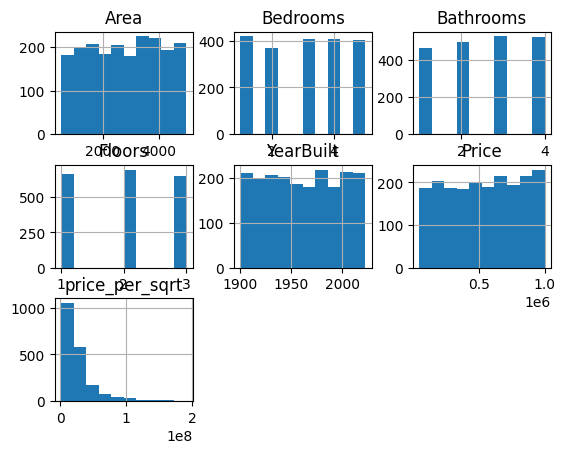

In [20]:

House_pricing.hist()

<Axes: xlabel='YearBuilt', ylabel='Density'>

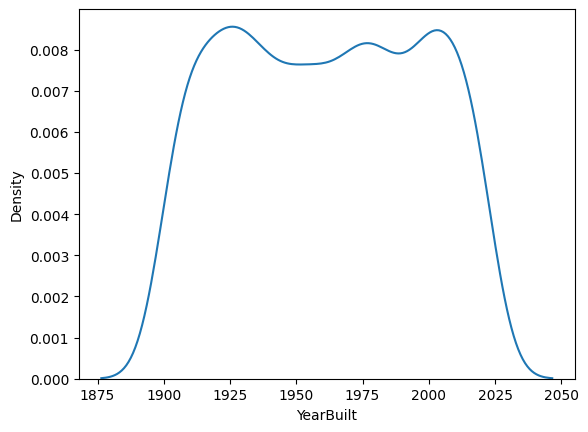

In [21]:
import seaborn as sns
sns.kdeplot(House_pricing['YearBuilt'])

<Axes: xlabel='Area', ylabel='Density'>

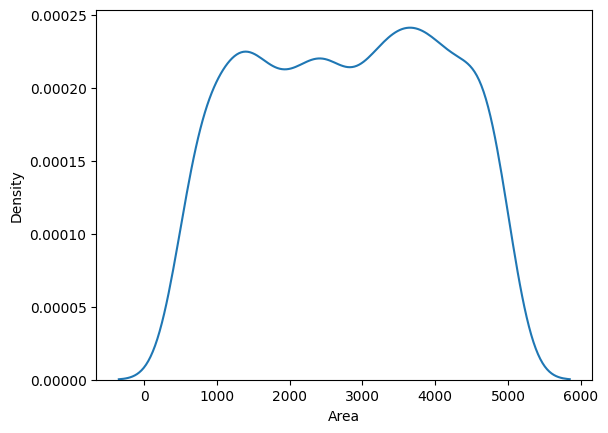

In [22]:
sns.kdeplot(House_pricing['Area'])

<Axes: xlabel='YearBuilt', ylabel='Density'>

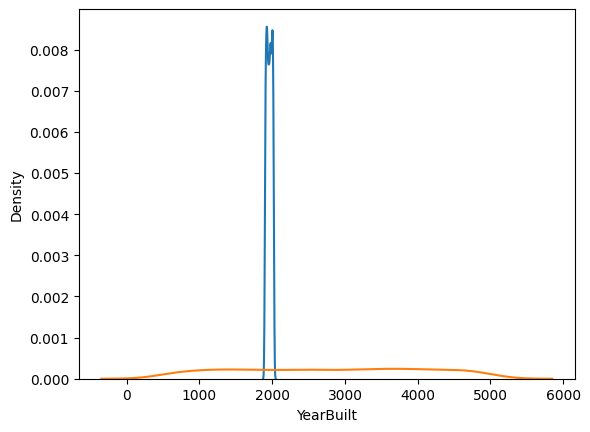

In [23]:

sns.kdeplot(House_pricing['YearBuilt'])
sns.kdeplot(House_pricing['Area'])

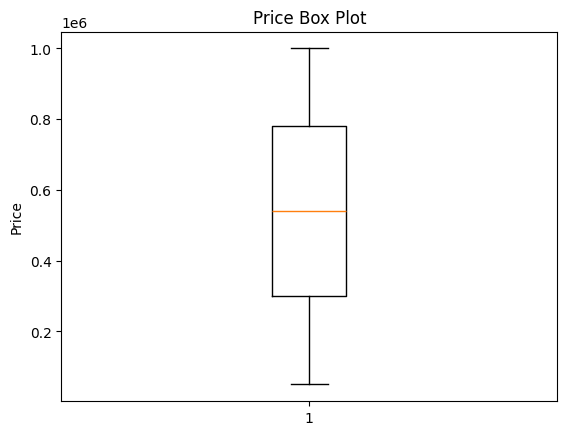

In [24]:
# Boxplot of house prices
plt.boxplot(House_pricing['Price'])
plt.title("Price Box Plot")
plt.ylabel("Price")
plt.show()

In [25]:
price_dist=House_pricing.groupby('Bedrooms').mean('Price')
price_dist

,Area,Bathrooms,Floors,YearBuilt,Price,price_per_sqrt
Bedrooms,,,,,,
1,2777.107656,2.578947,1.964115,1962.509569,530561.622010,2.793681e+07
2,2630.309783,2.565217,2.013587,1960.125000,545546.521739,2.999569e+07
3,2765.990148,2.509852,1.987685,1963.298030,546977.894089,2.733313e+07
4,2856.503704,2.587654,2.012346,1960.511111,533696.930864,2.544226e+07
5,2887.736973,2.521092,1.992556,1960.622829,532500.124069,2.492401e+07


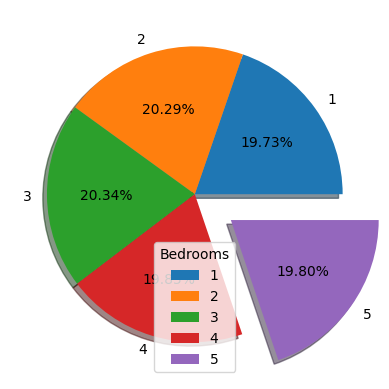

In [26]:

# Creating a pie chart with explode and shadow
my_labels=[1,2,3,4,5]
plt.pie(price_dist['Price'],labels=my_labels,autopct='%1.2f%%',explode=(0,0,0,0,0.3),shadow=True)
plt.legend(title="Bedrooms")
plt.show()

In [27]:

s=House_pricing.groupby('Bathrooms').mean('Price')
s

,Area,Bedrooms,Floors,YearBuilt,Price,price_per_sqrt
Bathrooms,,,,,,
1,2784.422993,3.047722,1.937093,1962.709328,558757.752711,2.874040e+07
2,2709.714575,3.014170,1.993927,1960.437247,516589.876518,2.671733e+07
3,2815.263359,2.938931,2.041985,1960.141221,540201.713740,2.638400e+07
4,2831.099808,3.019194,1.994242,1962.596929,536478.481766,2.665803e+07


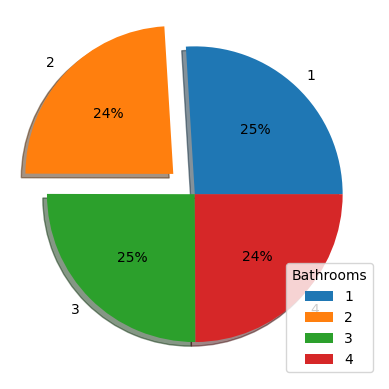

In [28]:

# Creating a pie chart with explode and shadow
my_labels=[1,2,3,4]
plt.pie(s['Price'],labels=my_labels,autopct='%d%%',explode=(0,0.2,0,0),shadow=True)
plt.legend(title='Bathrooms')
plt.show()

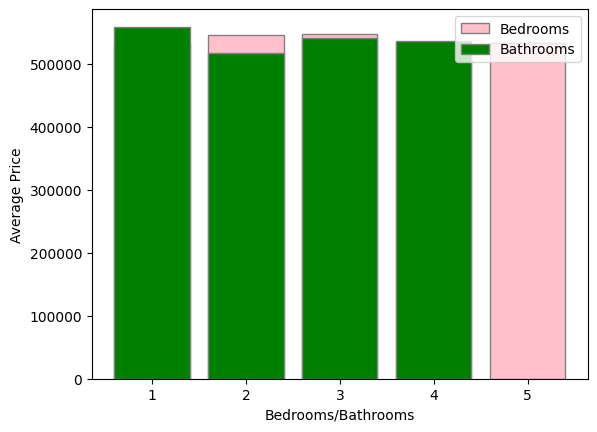

In [29]:

plt.bar(price_dist.index,price_dist['Price'],color='pink',edgecolor='grey',label='Bedrooms')
plt.bar(s.index,s['Price'],color='green',edgecolor='grey',label='Bathrooms')
plt.xlabel('Bedrooms/Bathrooms')
plt.ylabel('Average Price')
plt.legend()
plt.show()

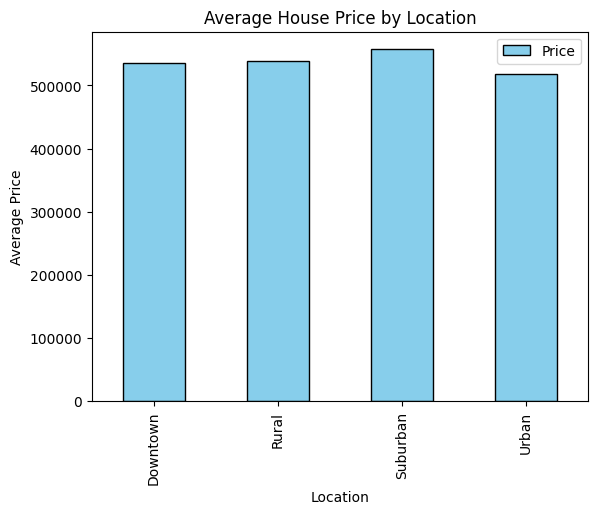

In [30]:

avg_price = House_pricing.groupby("Location")[["Price"]].mean()
avg_price.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Average House Price by Location")
plt.ylabel("Average Price")
plt.xlabel("Location")
plt.show()


##🧠 SQL Analysis

In [31]:

import sqlite3

In [32]:

# Connecting to an in-memory SQLite database
house=sqlite3.connect("/content/House Price Prediction Dataset.db")

In [33]:

# Saving the DataFrame as an SQL table
conn = sqlite3.connect("house_prices.db")
House_pricing.to_sql("house_prices", conn, if_exists="replace", index=False)

2000

In [34]:

# Querying all houses with price > 150000
query = "SELECT * FROM house_prices WHERE Price > 150000"
result = pd.read_sql_query(query, conn)
print(result)


      Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0     4272         5          4       3       1958  Downtown  Excellent   
1     3592         2          2       3       1938  Downtown       Good   
2      966         4          2       2       1902  Suburban       Fair   
3     4926         1          4       2       1975  Downtown       Fair   
4     3671         1          1       2       1948     Rural       Poor   
...    ...       ...        ...     ...        ...       ...        ...   
1799  4994         5          4       3       1923  Suburban       Poor   
1800  3046         5          2       1       2019  Suburban       Poor   
1801  1062         5          1       2       1903     Rural       Poor   
1802  4062         3          1       2       1936     Urban  Excellent   
1803  2989         5          1       3       1903  Suburban       Fair   

     Garage   Price  price_per_sqrt  
0        No  424998    9.948455e+06  
1        No  266746    

In [35]:

query = 'SELECT DISTINCT Location FROM house_prices'
location = pd.read_sql_query(query, conn)
print(location)


   Location
0  Downtown
1  Suburban
2     Urban
3     Rural


In [36]:
# Filtering houses located in Rural areas
query='SELECT * FROM house_prices WHERE Location="Rural"'
result=pd.read_sql_query(query,conn)
print(result)


     Area  Bedrooms  Bathrooms  Floors  YearBuilt Location  Condition Garage  \
0    3671         1          1       2       1948    Rural       Poor    Yes   
1     630         2          2       1       1932    Rural       Poor    Yes   
2    1684         1          1       1       2004    Rural       Good     No   
3    2306         2          2       3       1976    Rural       Poor    Yes   
4    4390         1          1       1       2020    Rural       Poor     No   
..    ...       ...        ...     ...        ...      ...        ...    ...   
469  2168         2          4       1       2010    Rural       Fair     No   
470   647         5          3       3       1919    Rural  Excellent     No   
471  4397         4          1       2       1981    Rural       Poor    Yes   
472   865         4          4       2       2020    Rural       Poor     No   
473  1062         5          1       2       1903    Rural       Poor     No   

      Price  price_per_sqrt  
0    4487

In [37]:
query='SELECT *FROM house_prices WHERE YearBuilt==2025'
result=pd.read_sql_query(query,conn)
print(result)

Empty DataFrame
Columns: [Area, Bedrooms, Bathrooms, Floors, YearBuilt, Location, Condition, Garage, Price, price_per_sqrt]
Index: []


In [38]:

query='SELECT *FROM house_prices WHERE YearBuilt==2023'
result=pd.read_sql_query(query,conn)
print(result)

    Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition Garage  \
0   4514         5          1       1       2023     Urban       Fair     No   
1   2348         1          4       1       2023     Urban  Excellent     No   
2   4844         1          3       3       2023  Downtown       Poor     No   
3   4097         3          1       1       2023  Suburban       Good     No   
4   2643         1          3       1       2023  Downtown       Fair     No   
5   3469         1          4       2       2023  Suburban       Poor     No   
6   4310         4          3       1       2023  Suburban       Fair    Yes   
7   4098         3          3       1       2023     Rural       Poor     No   
8   4903         1          3       2       2023     Rural  Excellent     No   
9   2637         2          3       2       2023  Downtown       Fair     No   
10  1468         3          3       1       2023  Downtown  Excellent     No   
11  1093         2          1       1   

In [39]:
query='SELECT Condition, Garage FROM house_prices';
result=pd.read_sql_query(query,conn)
print(result)

      Condition Garage
0     Excellent     No
1     Excellent     No
2          Good     No
3          Fair    Yes
4          Fair    Yes
...         ...    ...
1995       Poor     No
1996       Poor    Yes
1997       Poor     No
1998  Excellent    Yes
1999       Fair     No

[2000 rows x 2 columns]


In [40]:
query='SELECT *FROM house_prices WHERE YearBuilt=2023 AND Condition ="Fair"'
result=pd.read_sql_query(query,conn)
print(result)


   Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location Condition Garage  \
0  4514         5          1       1       2023     Urban      Fair     No   
1  2643         1          3       1       2023  Downtown      Fair     No   
2  4310         4          3       1       2023  Suburban      Fair    Yes   
3  2637         2          3       2       2023  Downtown      Fair     No   

    Price  price_per_sqrt  
0  959222    2.124993e+07  
1  628528    2.378086e+07  
2  903906    2.097230e+07  
3  305560    1.158741e+07  


In [41]:
query='SELECT *FROM house_prices ORDER BY Bedrooms'
result=pd.read_sql_query(query,conn)
print(result)

      Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0     4926         1          4       2       1975  Downtown       Fair   
1     3944         1          2       1       1906     Urban       Poor   
2     3671         1          1       2       1948     Rural       Poor   
3     1269         1          4       2       1947  Suburban       Poor   
4     1684         1          1       1       2004     Rural       Good   
...    ...       ...        ...     ...        ...       ...        ...   
1995   647         5          3       3       1919     Rural  Excellent   
1996  4994         5          4       3       1923  Suburban       Poor   
1997  3046         5          2       1       2019  Suburban       Poor   
1998  1062         5          1       2       1903     Rural       Poor   
1999  2989         5          1       3       1903  Suburban       Fair   

     Garage   Price  price_per_sqrt  
0       Yes  636056    1.291222e+07  
1        No   93262    

## ✅ Conclusion
- The majority of high-priced houses are in urban areas.
- Rural houses tend to be more affordable.
- SQL with Pandas is a powerful tool for data analysis.
